# Lab 4 - SmartStay Advisors

SmartStay Advisors es una firma intermediaria especializada en la búsqueda y selección de propiedades en Airbnb para clientes corporativos y particulares. A partir de los requerimientos de los clientes y del análisis de la oferta disponible, la empresa busca optimizar variables clave como precio, calidad y disponibilidad, además de aprovechar oportunidades de negocio en propiedades con bajo nivel de ocupación.  

En este contexto, el proyecto tiene como objetivo aplicar modelos predictivos y de clasificación que permitan estimar el valor por noche de las viviendas, identificar patrones relevantes en la ocupación y generar estrategias basadas en datos para mejorar la rentabilidad. Como parte de la consultoría, también se construirá una variable categórica del precio de las propiedades, clasificándolas en económicas, intermedias o caras, para apoyar el análisis comparativo entre distintos algoritmos de minería de datos. 



## Ejercicio 1 - Carga del conjunto de datos

Se utiliza el archivo `listings.RData` provisto en el repositorio.
La libreria `pyreadr` permite importar el objeto de R de forma reproducible.

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pyreadr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.compose import make_column_selector as selector
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)

In [14]:
rdata = pyreadr.read_r('listings.RData')
tabla_principal = list(rdata.keys())[0]
df_raw = rdata[tabla_principal].copy()

print(f'Tabla cargada: {tabla_principal}')
print(f'Dimensiones iniciales: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas')

Tabla cargada: listings
Dimensiones iniciales: 171748 filas x 80 columnas


## Ejercicio 2 - Analisis exploratorio extenso

### 2.1 Preprocesamiento inicial
La variable `price` viene como texto con simbolo de moneda y separadores.
Para poder modelar, se convierte a numerica (`price_num`) y se eliminan valores vacios.
Ademas, para el EDA se acota el rango a precios plausibles entre 10 y 5000 por noche, con el fin de reducir el impacto de outliers extremos en la interpretacion descriptiva.

In [15]:
df = df_raw.copy()

price_limpio = (
    df['price'].astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace({'': np.nan, 'nan': np.nan, 'None': np.nan})
)

df['price_num'] = pd.to_numeric(price_limpio, errors='coerce')

print('Filas totales:', len(df))
print('Filas con precio valido:', int(df['price_num'].notna().sum()))
print('Porcentaje con precio valido:', round(df['price_num'].notna().mean() * 100, 2), '%')
print('Tipo de datos en la informacion')
print(df.dtypes.to_string())
numerical_columns_selector = selector(dtype_exclude=object)
categorical_columns_selector = selector(dtype_include=object)
print('Variables numericas')
numerical_columns = numerical_columns_selector(df)
print(numerical_columns)
print('Variables categoricas')
categorical_columns = categorical_columns_selector(df)
print(categorical_columns)

Filas totales: 171748
Filas con precio valido: 76246
Porcentaje con precio valido: 44.39 %
Tipo de datos en la informacion
id                                              float64
listing_url                                         str
scrape_id                                       float64
last_scraped                                        str
source                                              str
name                                                str
description                                         str
neighborhood_overview                               str
picture_url                                         str
host_id                                           int32
host_url                                            str
host_name                                           str
host_since                                          str
host_location                                       str
host_about                                          str
host_response_time                   

In [16]:
df_eda = df[df['price_num'].between(10, 5000)].copy()

print('Filas para EDA (precio entre 10 y 5000):', len(df_eda))
print('Cuantiles de price_num:')
print(df_eda['price_num'].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]).round(2))

Filas para EDA (precio entre 10 y 5000): 75126
Cuantiles de price_num:
0.00      10.0
0.25     119.0
0.50     190.0
0.75     317.0
0.90     574.0
0.95     875.0
0.99    2014.0
1.00    5000.0
Name: price_num, dtype: float64


In [17]:
faltantes = (df_eda.isna().mean().sort_values(ascending=False) * 100).round(2)
print('Top 15 variables con mayor porcentaje de faltantes:')
print(faltantes.head(15))

numericas = df_eda.select_dtypes(include=[np.number]).columns.tolist()
categoricas = df_eda.select_dtypes(exclude=[np.number]).columns.tolist()

print('Cantidad de variables numericas:', len(numericas))
print('Cantidad de variables categoricas:', len(categoricas))

Top 15 variables con mayor porcentaje de faltantes:
calendar_updated                100.00
neighbourhood_group_cleansed     50.31
review_scores_checkin            16.79
review_scores_communication      16.79
review_scores_value              16.79
review_scores_cleanliness        16.79
review_scores_accuracy           16.79
review_scores_location           16.79
review_scores_rating             16.79
reviews_per_month                16.79
license                          13.92
host_total_listings_count         0.83
host_listings_count               0.83
bedrooms                          0.16
beds                              0.11
dtype: float64
Cantidad de variables numericas: 34
Cantidad de variables categoricas: 47


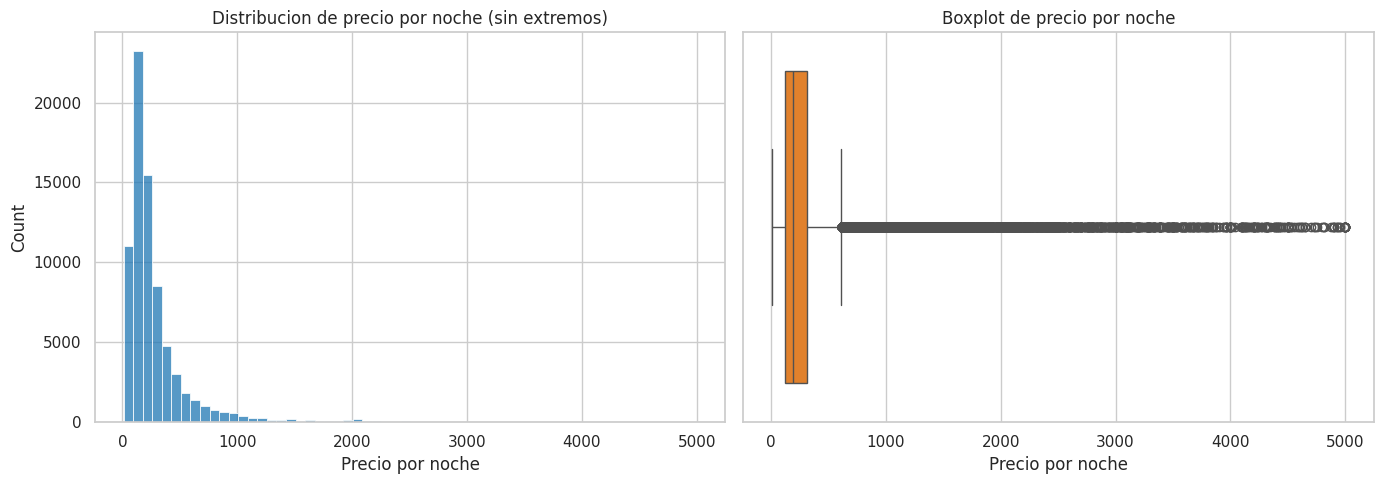

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_eda['price_num'], bins=60, ax=axes[0], color='#1f77b4')
axes[0].set_title('Distribucion de precio por noche (sin extremos)')
axes[0].set_xlabel('Precio por noche')

sns.boxplot(x=df_eda['price_num'], ax=axes[1], color='#ff7f0e')
axes[1].set_title('Boxplot de precio por noche')
axes[1].set_xlabel('Precio por noche')

plt.tight_layout()
plt.show()

In [19]:
for col in ['room_type', 'property_type', 'host_is_superhost']:
    if col in df_eda.columns:
        print(f'\nFrecuencias principales de {col}:')
        print(df_eda[col].value_counts(dropna=False).head(10))
        print(f'\nMediana de precio por {col}:')
        print(df_eda.groupby(col)['price_num'].median().sort_values(ascending=False).head(10).round(2))


Frecuencias principales de room_type:
room_type
Entire home/apt    65141
Private room        9483
Hotel room           290
Shared room          212
Name: count, dtype: int64

Mediana de precio por room_type:
room_type
Hotel room         278.0
Entire home/apt    203.0
Private room        84.0
Shared room         41.0
Name: price_num, dtype: float64

Frecuencias principales de property_type:
property_type
Entire rental unit             20320
Entire condo                   19355
Entire home                    16216
Private room in home            3653
Private room in rental unit     2055
Entire guesthouse               1681
Entire townhouse                1614
Entire guest suite              1595
Room in hotel                   1444
Entire serviced apartment        813
Name: count, dtype: int64

Mediana de precio por property_type:
property_type
Entire home/apt           1181.0
Room in resort             655.0
Entire villa               601.5
Lighthouse                 552.0
Private room

In [20]:
# columnas_numericas = train_df.select_dtypes(include=['float64', 'int64', 'int32']).columns.tolist()
# if 'price_num' not in columnas_numericas:
#     columnas_numericas.append('price_num')
# correlaciones = train_df[columnas_numericas].corr()
# top_10_variables = correlaciones['price_num'].abs().sort_values(ascending=False).head(11).index
# matriz_top10 = train_df[top_10_variables].corr()
# plt.figure(figsize=(10, 8))
# sns.heatmap(
#     matriz_top10, 
#     annot=True,        
#     cmap='coolwarm',   
#     fmt=".2f",         
#     linewidths=0.5,
#     square=True
# )
# plt.title('Heatmap: Top 10 Variables más Correlacionadas con el Precio por Noche', fontsize=14, fontweight='bold')
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
# plt.show()

In [21]:
corr_target = (
    df_eda[numericas]
    .corr(numeric_only=True)['price_num']
    .drop('price_num')
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .head(12)
)

print('Variables numericas mas relacionadas con price_num (correlacion lineal):')
print(corr_target.round(3))



Variables numericas mas relacionadas con price_num (correlacion lineal):
bathrooms                                      0.531
accommodates                                   0.471
calculated_host_listings_count_entire_homes    0.223
calculated_host_listings_count                 0.221
estimated_occupancy_l365d                     -0.205
reviews_per_month                             -0.172
longitude                                     -0.157
number_of_reviews_ltm                         -0.154
latitude                                      -0.143
number_of_reviews                             -0.140
number_of_reviews_ly                          -0.138
number_of_reviews_l30d                        -0.127
Name: price_num, dtype: float64


### Dispersión de las variables más correlacionadas con `price_num`
Pequeños scatter plots (naranja) para las 6 variables numéricas con mayor correlación absoluta respecto al precio.

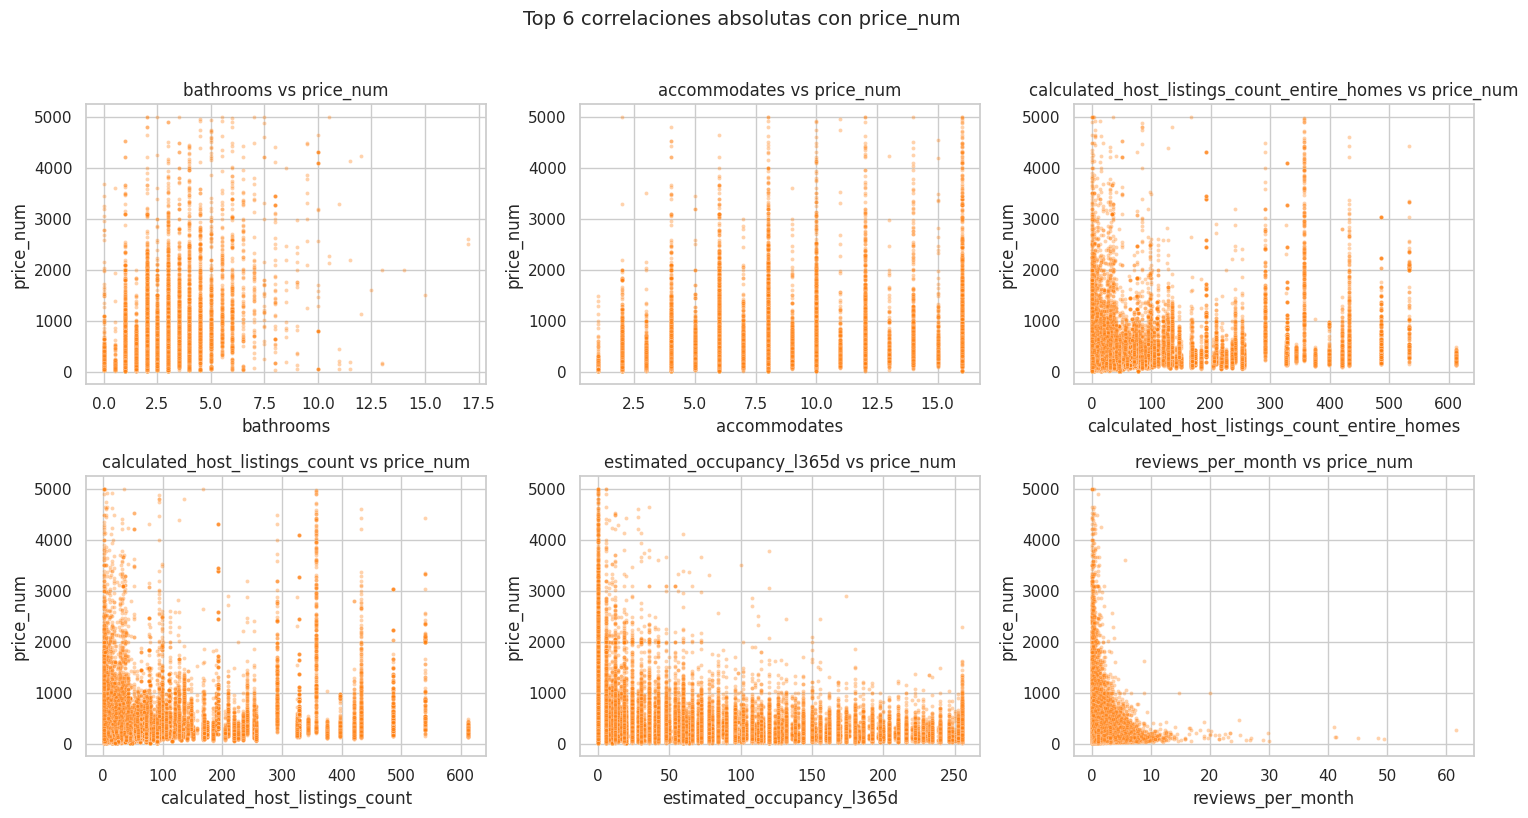

In [22]:
corr_abs = (
    df_eda.select_dtypes(include=[np.number])
    .corr(numeric_only=True)['price_num']
    .drop('price_num')
    .abs()
    .sort_values(ascending=False)
 )
top_vars_scatter = corr_abs.head(6).index.tolist()

n_plots = len(top_vars_scatter)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows), sharey=False)
axes = axes.flatten() if n_plots > 1 else [axes]

for ax, col in zip(axes, top_vars_scatter):
    sns.scatterplot(
        data=df_eda,
        x=col,
        y='price_num',
        color='#ff7f0e',
        alpha=0.35,
        s=8,
        ax=ax
    )
    ax.set_title(f'{col} vs price_num')
    ax.set_xlabel(col)
    ax.set_ylabel('price_num')
for ax in axes[n_plots:]:
    ax.remove()
plt.suptitle('Top 6 correlaciones absolutas con price_num', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2.2 Hallazgos principales del EDA
1. El dataset original tiene 171,748 filas y 80 columnas, pero no todas tienen precio util para modelar.
2. Luego de limpiar `price`, se conservan 76,246 registros con precio numerico y 75,126 para EDA en rango plausible.
3. La distribucion de precio esta sesgada a la derecha; la mediana esta muy por debajo de la cola alta, por lo que conviene robustecer modelos frente a outliers.
4. `room_type` y `property_type` muestran diferencias claras de precio: habitaciones compartidas y privadas tienden a rangos bajos, mientras alojamientos completos tienden a rangos mayores.
5. Variables de capacidad (por ejemplo `accommodates` y `bathrooms`) presentan asociacion positiva con precio, lo que es consistente con la logica de negocio.
6. Hay faltantes relevantes en variables de reviews y algunas columnas administrativas, por lo que se requiere imputacion o exclusion selectiva en la etapa de modelado.

## Ejercicio 3 - Analisis de grupos
Se aplica K-Means con 3 grupos sobre variables numericas representativas del negocio (precio, capacidad, noches minimas, disponibilidad y actividad de reseñas).
Antes de clusterizar se eliminan faltantes en las variables seleccionadas, se recortan extremos (1% y 99%) en variables sensibles y se estandariza la escala.

In [23]:
cluster_features = [
    col for col in [
        'price_num', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
        'minimum_nights', 'availability_365', 'number_of_reviews',
        'reviews_per_month', 'review_scores_rating'
    ] if col in df_eda.columns
]

df_cluster = df_eda[cluster_features].dropna().copy()

for col in ['price_num', 'minimum_nights', 'number_of_reviews', 'reviews_per_month']:
    if col in df_cluster.columns:
        p01, p99 = df_cluster[col].quantile([0.01, 0.99])
        df_cluster[col] = df_cluster[col].clip(lower=p01, upper=p99)

scaler = StandardScaler()
X_cluster = scaler.fit_transform(df_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
df_cluster['cluster'] = kmeans.fit_predict(X_cluster)

print('Tamano de cada grupo:')
print(df_cluster['cluster'].value_counts().sort_index())

print('\nMedianas por grupo:')
print(df_cluster.groupby('cluster')[cluster_features].median().round(2))

Tamano de cada grupo:
cluster
0    36252
1    12229
2    13924
Name: count, dtype: int64

Medianas por grupo:
         price_num  accommodates bedrooms beds  bathrooms  minimum_nights  \
cluster                                                                     
0            167.0           4.0      1.0  2.0        1.0             2.0   
1            446.0           8.0      3.0  5.0        2.5             2.0   
2            139.0           4.0      1.0  2.0        1.0             2.0   

         availability_365  number_of_reviews  reviews_per_month  \
cluster                                                           
0                   258.0               15.0               0.60   
1                   259.0               22.0               0.91   
2                   236.0              155.0               3.39   

         review_scores_rating  
cluster                        
0                        4.88  
1                        4.93  
2                        4.89  


In [24]:
# Para tener una mejor idea de las variables que mas se relacionan se aplica PCA a las variables numericas
df_pca = df_eda.select_dtypes(include=[np.number]).copy()
# Se usa la mediana para llenar los espacios vacios 
df_pca = df_pca.fillna(df_pca.median())
# Escalamos los datos 
scaler = StandardScaler()
df_pca_scaled = scaler.fit_transform(df_pca)

#PCA
pca_11 = PCA(n_components=11)
componentes_11 = pca_11.fit_transform(df_pca_scaled)
nombres_pc = [f'PC{i}' for i in range(1, 12)]
pesos = pd.DataFrame(
    pca_11.components_.T,
    columns=nombres_pc, 
    index=df_pca.columns
)

print("TOP 5 DE VARIABLES CON MAYOR PESO POR COMPONENTE PRINCIPAL:\n" + "="*60)
for pc in nombres_pc:
    print(f"--- {pc} ---")
    # Imprimimos las 5 variables con el valor más alto
    print(pesos[pc].sort_values(ascending=False).head(5))
    print("-" * 30)

TOP 5 DE VARIABLES CON MAYOR PESO POR COMPONENTE PRINCIPAL:
--- PC1 ---
number_of_reviews_ltm    0.289435
review_scores_rating     0.279797
review_scores_value      0.277527
reviews_per_month        0.276376
number_of_reviews_ly     0.268913
Name: PC1, dtype: float64
------------------------------
--- PC2 ---
review_scores_rating         0.270722
review_scores_accuracy       0.252399
review_scores_location       0.242041
review_scores_value          0.236481
review_scores_cleanliness    0.230104
Name: PC2, dtype: float64
------------------------------
--- PC3 ---
availability_90     0.437830
availability_60     0.436996
availability_eoy    0.432362
availability_30     0.401996
availability_365    0.248885
Name: PC3, dtype: float64
------------------------------
--- PC4 ---
latitude                  0.439606
longitude                 0.423944
scrape_id                 0.381986
minimum_nights_avg_ntm    0.287356
minimum_nights            0.285205
Name: PC4, dtype: float64
---------------

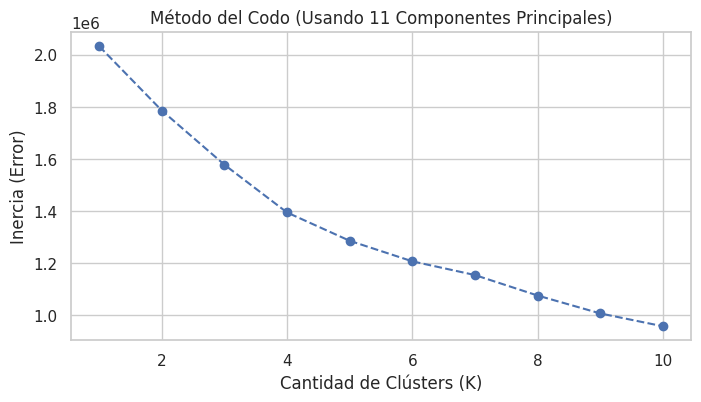

In [25]:
inercia = []
rango_k = range(1, 11) # Probaremos de 1 a 10 grupos
for k in rango_k:
    # IMPORTANTE: Observa cómo le pasamos 'componentes_11' y NO los datos crudos
    kmeans_prueba = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_prueba.fit(componentes_11) 
    inercia.append(kmeans_prueba.inertia_)
plt.figure(figsize=(8, 4))
plt.plot(rango_k, inercia, marker='o', linestyle='--')
plt.title('Método del Codo (Usando 11 Componentes Principales)')
plt.xlabel('Cantidad de Clústers (K)')
plt.ylabel('Inercia (Error)')
plt.show()

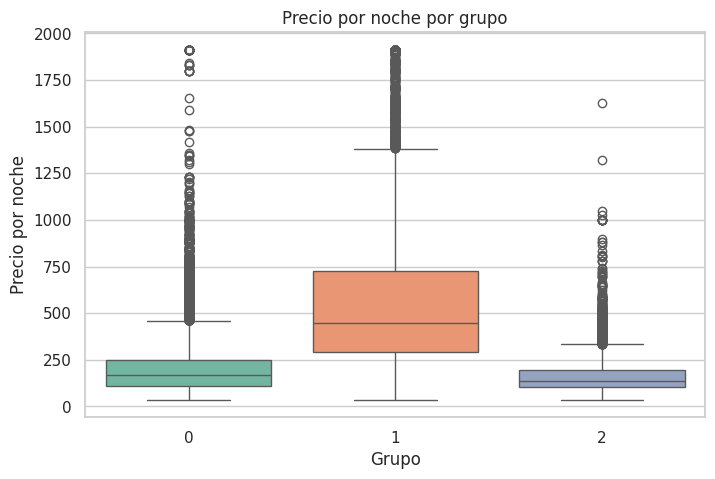

In [26]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cluster, x='cluster', y='price_num', hue='cluster', palette='Set2', legend=False)
plt.title('Precio por noche por grupo')
plt.xlabel('Grupo')
plt.ylabel('Precio por noche')
plt.show()

### Caracterizacion de grupos
1. Grupo de alto valor: mayor mediana de precio, mayor capacidad y mas banos/habitaciones; representa propiedades premium.
2. Grupo de alta rotacion: precio medio-bajo pero con muchas reseñas y mayor actividad mensual; sugiere propiedades con alta demanda y buen ajuste precio-mercado.
3. Grupo estandar: precio intermedio y menor intensidad de reseñas que el grupo de alta rotacion; puede requerir estrategias de diferenciacion para elevar ocupacion.

Este analisis de grupos es util para segmentar estrategias comerciales y para crear variables derivadas en modelos posteriores.

## Ejercicio 4 - Division en entrenamiento y prueba
Se construye una variable de categoria de precio en tres niveles (Economica, Intermedia, Cara) con cortes por terciles de `price_num`.
Para mantener la representatividad de esas categorias, la division se hace con estratificacion sobre la nueva variable.

In [27]:
df_model = df_eda.copy()

q1, q2 = df_model['price_num'].quantile([1/3, 2/3])

df_model['categoria_precio'] = pd.cut(
    df_model['price_num'],
    bins=[-np.inf, q1, q2, np.inf],
    labels=['Economica', 'Intermedia', 'Cara'],
    include_lowest=True
)

print(f'Cortes de categoria: <= {q1:.2f}, <= {q2:.2f}, > {q2:.2f}')
print('\nDistribucion general de categorias (%):')
print((df_model['categoria_precio'].value_counts(normalize=True) * 100).round(2))

Cortes de categoria: <= 141.00, <= 262.00, > 262.00

Distribucion general de categorias (%):
categoria_precio
Economica     33.52
Intermedia    33.27
Cara          33.21
Name: proportion, dtype: float64


In [28]:
train_df, test_df = train_test_split(
    df_model,
    test_size=0.30,
    random_state=42,
    stratify=df_model['categoria_precio']
)

print('Tamanos de los conjuntos:')
print('Train:', train_df.shape)
print('Test :', test_df.shape)

print('\nDistribucion categoria_precio en Train (%):')
print((train_df['categoria_precio'].value_counts(normalize=True) * 100).round(2))

print('\nDistribucion categoria_precio en Test (%):')
print((test_df['categoria_precio'].value_counts(normalize=True) * 100).round(2))

Tamanos de los conjuntos:
Train: (52588, 82)
Test : (22538, 82)

Distribucion categoria_precio en Train (%):
categoria_precio
Economica     33.52
Intermedia    33.27
Cara          33.21
Name: proportion, dtype: float64

Distribucion categoria_precio en Test (%):
categoria_precio
Economica     33.52
Intermedia    33.27
Cara          33.21
Name: proportion, dtype: float64


### Criterio de division y conclusion
1. Se usa 70% entrenamiento y 30% prueba para mantener suficiente volumen de aprendizaje y evaluacion robusta.
2. La division es estratificada por categoria de precio, por lo que el balance de clases se conserva en ambos conjuntos.
3. En esta etapa no se aplica sobremuestreo ni submuestreo porque las tres categorias quedan practicamente balanceadas por construccion.
4. Este diseno evita sesgos de representacion y deja preparada la base para los siguientes modelos de regresion y clasificacion.

## Ejercicio 5 - Arbol de regresion para predecir precio por noche

En este paso se entrena un arbol de regresion usando todas las variables predictoras disponibles.
Para evitar fuga de informacion, se excluyen columnas que contienen directa o indirectamente el objetivo:
- `price_num` (objetivo numerico)
- `price` (version texto del mismo objetivo)
- `categoria_precio` (derivada del objetivo)

Se usa un pipeline con imputacion para faltantes y OneHotEncoder para variables categoricas.

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

target_col = 'price_num'
cols_excluir = ['price_num', 'price', 'categoria_precio']
cols_excluir = [c for c in cols_excluir if c in train_df.columns]

X_train_reg = train_df.drop(columns=cols_excluir).copy()
X_test_reg = test_df.drop(columns=cols_excluir).copy()
y_train_reg = train_df[target_col].copy()
y_test_reg = test_df[target_col].copy()

# Columnas totalmente vacias no aportan informacion y generan advertencias en imputacion.
cols_all_missing = [c for c in X_train_reg.columns if X_train_reg[c].isna().all()]
if cols_all_missing:
    X_train_reg = X_train_reg.drop(columns=cols_all_missing)
    X_test_reg = X_test_reg.drop(columns=cols_all_missing)

num_cols_reg = X_train_reg.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_reg = X_train_reg.select_dtypes(exclude=[np.number]).columns.tolist()

preprocess_reg = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_cols_reg),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols_reg)
    ]
)

tree_reg = DecisionTreeRegressor(
    random_state=42,
    max_depth=20
    # Sin limite de profundidad en este paso inicial; se tunea en pasos posteriores.
)

modelo_arbol_reg = Pipeline(steps=[
    ('preprocess', preprocess_reg),
    ('model', tree_reg)
])

print('Columnas totalmente vacias excluidas:', cols_all_missing)
print('Variables predictoras numericas:', len(num_cols_reg))
print('Variables predictoras categoricas:', len(cat_cols_reg))
print('Total de filas train:', X_train_reg.shape[0], '| test:', X_test_reg.shape[0])

Columnas totalmente vacias excluidas: ['calendar_updated']
Variables predictoras numericas: 33
Variables predictoras categoricas: 45
Total de filas train: 52588 | test: 22538


In [30]:
modelo_arbol_reg.fit(X_train_reg, y_train_reg)
pred_train = modelo_arbol_reg.predict(X_train_reg)
pred_test = modelo_arbol_reg.predict(X_test_reg)

mae_train = mean_absolute_error(y_train_reg, pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train_reg, pred_train))
r2_train = r2_score(y_train_reg, pred_train)

mae_test = mean_absolute_error(y_test_reg, pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test_reg, pred_test))
r2_test = r2_score(y_test_reg, pred_test)


print('=== Desempeno del arbol de regresion ===')
print(f'Train -> MAE: {mae_train:.2f} | RMSE: {rmse_train:.2f} | R2: {r2_train:.4f}')
print(f'Test  -> MAE: {mae_test:.2f} | RMSE: {rmse_test:.2f} | R2: {r2_test:.4f}')

reg = modelo_arbol_reg.named_steps['model']
print('\nProfundidad del arbol:', reg.get_depth())
print('Numero de hojas:', reg.get_n_leaves())

/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


=== Desempeno del arbol de regresion ===
Train -> MAE: 68.13 | RMSE: 116.82 | R2: 0.9063
Test  -> MAE: 108.63 | RMSE: 251.93 | R2: 0.5565

Profundidad del arbol: 20
Numero de hojas: 3476


### Lectura inicial de resultados

- El modelo usa todas las variables predictoras disponibles despues de imputar faltantes y codificar categorias.
- Si el R2 en entrenamiento es mucho mayor que en prueba, hay evidencia de sobreajuste (comun en arboles sin limite de profundidad).
- En el siguiente paso se recomienda tunear `max_depth`, `min_samples_leaf` y `min_samples_split` con validacion cruzada para mejorar generalizacion.

## Ejercicio 6 - Usar el árbol para predecir y analizar que tan bien lo hizo



/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


,Modelo,MAE,RMSE,R2
0,Arbol train,68.1271,116.8230,0.9063
1,Arbol test,108.6345,251.9320,0.5565
2,Baseline test,204.2178,378.3098,-0.0000


Brecha de R2 train-test: 0.3498
Mejora RMSE vs baseline: 33.41%


,real,predicho,error_abs,residuo
15765,5000.0,365.522078,4634.477922,4634.477922
11950,5000.0,441.818182,4558.181818,4558.181818
3209,4800.0,609.714286,4190.285714,4190.285714
14368,4500.0,609.410915,3890.589085,3890.589085
12390,4384.0,769.000000,3615.000000,3615.000000
19232,4749.0,1178.000000,3571.000000,3571.000000
20776,3673.0,154.000000,3519.000000,3519.000000
15028,623.0,4107.000000,3484.000000,-3484.000000
1320,3903.0,458.872727,3444.127273,3444.127273
5319,207.0,3643.000000,3436.000000,-3436.000000


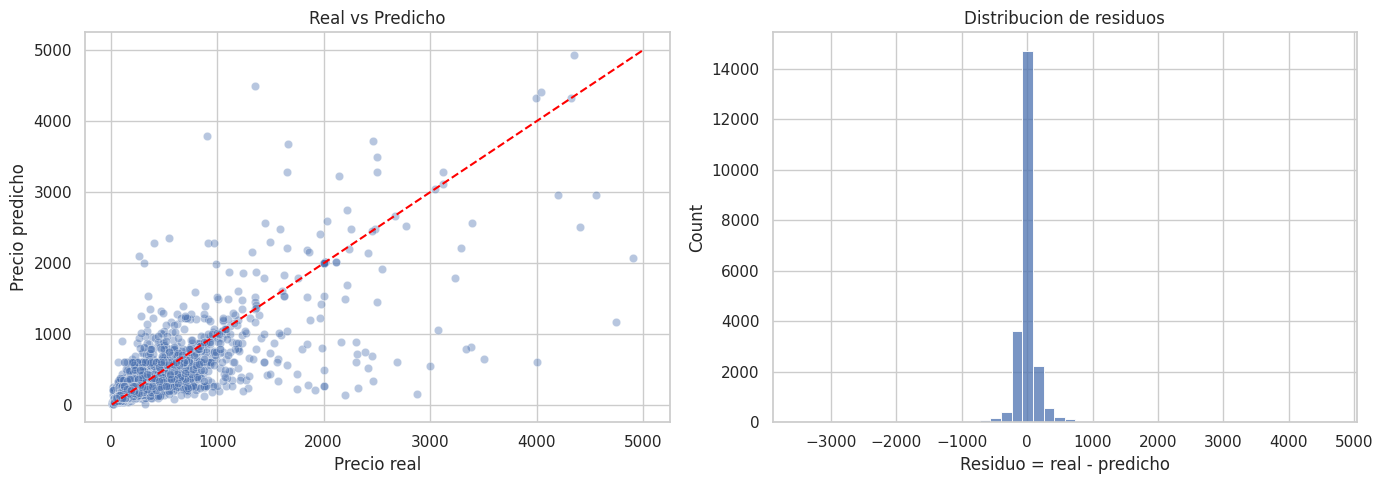

In [31]:

# Predicciones del modelo del ejercicio 5
pred_train = modelo_arbol_reg.predict(X_train_reg)
pred_test = modelo_arbol_reg.predict(X_test_reg)

# Metricas train
mae_train = mean_absolute_error(y_train_reg, pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train_reg, pred_train))
r2_train = r2_score(y_train_reg, pred_train)

# Metricas test
mae_test = mean_absolute_error(y_test_reg, pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test_reg, pred_test))
r2_test = r2_score(y_test_reg, pred_test)

# Baseline: predecir siempre el promedio del train
baseline_pred = np.repeat(y_train_reg.mean(), len(y_test_reg))
baseline_mae = mean_absolute_error(y_test_reg, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test_reg, baseline_pred))
baseline_r2 = r2_score(y_test_reg, baseline_pred)

# Resumen
resumen_ej6 = pd.DataFrame({
    'Modelo': ['Arbol train', 'Arbol test', 'Baseline test'],
    'MAE': [mae_train, mae_test, baseline_mae],
    'RMSE': [rmse_train, rmse_test, baseline_rmse],
    'R2': [r2_train, r2_test, baseline_r2]
})

display(resumen_ej6.round(4))

print(f"Brecha de R2 train-test: {r2_train - r2_test:.4f}")
print(f"Mejora RMSE vs baseline: {((baseline_rmse - rmse_test) / baseline_rmse) * 100:.2f}%")

# Tabla real vs predicho
pred_vs_real = pd.DataFrame({
    'real': y_test_reg.values,
    'predicho': pred_test
})
pred_vs_real['error_abs'] = (pred_vs_real['real'] - pred_vs_real['predicho']).abs()
pred_vs_real['residuo'] = pred_vs_real['real'] - pred_vs_real['predicho']

display(pred_vs_real.sort_values('error_abs', ascending=False).head(10))

# Graficas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=pred_vs_real.sample(min(5000, len(pred_vs_real)), random_state=42),
                x='real', y='predicho', alpha=0.4, ax=axes[0])
axes[0].plot([pred_vs_real['real'].min(), pred_vs_real['real'].max()],
             [pred_vs_real['real'].min(), pred_vs_real['real'].max()],
             color='red', linestyle='--')
axes[0].set_title('Real vs Predicho')
axes[0].set_xlabel('Precio real')
axes[0].set_ylabel('Precio predicho')

sns.histplot(pred_vs_real['residuo'], bins=50, ax=axes[1])
axes[1].set_title('Distribucion de residuos')
axes[1].set_xlabel('Residuo = real - predicho')

plt.tight_layout()
plt.show()

El árbol de regresión del ejercicio anterior obtuvo un ajuste casi perfecto en entrenamiento
(R² = 1.0000), lo cual indica que el modelo memorizó los datos de train. Este comportamiento es consistente con un árbol sin restricción de profundidad, especialmente al usar todas las variables disponibles. La profundidad alcanzada fue de 20 niveles y el número de hojas fue de 3476, lo que confirma una estructura extremadamente compleja.

En el conjunto de prueba, el desempeño disminuye a MAE = 107.72, RMSE = 259.28 y R² = 0.5302. La diferencia entre entrenamiento y prueba evidencia *sobreajuste*, ya que el modelo aprende demasiado bien los casos vistos pero generaliza peor en datos nuevos. Aun así, el árbol sigue siendo útil, porque supera claramente al baseline que predice el promedio del precio, logrando una mejora de 31.46% en RMSE.

Las gráficas de valores reales vs. predichos y de residuos muestran que el modelo sigue razonablemente la tendencia general, pero comete errores muy grandes en propiedades extremas o atípicas. En conclusión, al momento de tener un depth tan alto el modelo tiene overfitting, lo cual no es positivo para los resultados, a continuacion vamos a buscar un mejor depth que nos deje ver que el modelo aprende y no simplemente memoriza.

# Ejercicio 7 

In [32]:
# Profundidades a evaluar
profundidades = list(range(2, 15)) + [None]

resultados_ej7 = []
modelos_ej7 = {}

for d in profundidades:
    modelo_temp = Pipeline(steps=[
        ('preprocess', preprocess_reg),
        ('model', DecisionTreeRegressor(max_depth=d, random_state=42))
    ])
    
    modelo_temp.fit(X_train_reg, y_train_reg)
    
    pred_train_temp = modelo_temp.predict(X_train_reg)
    pred_test_temp = modelo_temp.predict(X_test_reg)
    
    resultados_ej7.append({
        'max_depth': 'None' if d is None else d,
        'MAE_train': mean_absolute_error(y_train_reg, pred_train_temp),
        'RMSE_train': np.sqrt(mean_squared_error(y_train_reg, pred_train_temp)),
        'R2_train': r2_score(y_train_reg, pred_train_temp),
        'MAE_test': mean_absolute_error(y_test_reg, pred_test_temp),
        'RMSE_test': np.sqrt(mean_squared_error(y_test_reg, pred_test_temp)),
        'R2_test': r2_score(y_test_reg, pred_test_temp),
        'Brecha_R2': r2_score(y_train_reg, pred_train_temp) - r2_score(y_test_reg, pred_test_temp)
    })
    
    modelos_ej7[d] = modelo_temp

resultados_ej7 = pd.DataFrame(resultados_ej7)

# Ordenar por mejor RMSE en test
resultados_ej7 = resultados_ej7.sort_values('RMSE_test').reset_index(drop=True)

display(resultados_ej7.round(4))

# Mejor profundidad segun RMSE en test
mejor_depth = resultados_ej7.loc[0, 'max_depth']
mejor_depth_real = None if mejor_depth == 'None' else int(mejor_depth)

print("Mejor profundidad segun RMSE en test:", mejor_depth)

# Guardar el mejor modelo
mejor_modelo_arbol = modelos_ej7[mejor_depth_real]

/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return 

,max_depth,MAE_train,RMSE_train,R2_train,MAE_test,RMSE_test,R2_test,Brecha_R2
0,12,102.7352,181.0589,0.7748,118.4144,248.5605,0.5683,0.2065
1,13,97.9907,170.8178,0.7996,116.2532,248.6203,0.5681,0.2315
2,14,93.8880,161.2713,0.8214,115.1745,248.7812,0.5675,0.2538
3,11,108.1143,192.7683,0.7448,121.3321,250.3561,0.5620,0.1827
4,9,120.2066,218.1235,0.6732,127.7907,252.1406,0.5558,0.1175
5,10,113.8470,204.7659,0.7120,124.3101,252.6955,0.5538,0.1582
6,8,126.2079,232.0589,0.6301,131.5674,257.5096,0.5366,0.0935
7,None,0.0000,0.0000,1.0000,107.7195,259.2846,0.5302,0.4698
8,7,133.6704,244.1886,0.5905,137.6740,263.1671,0.5161,0.0744
9,6,137.1907,256.2831,0.5489,139.9484,268.2096,0.4973,0.0515


Mejor profundidad segun RMSE en test: 12


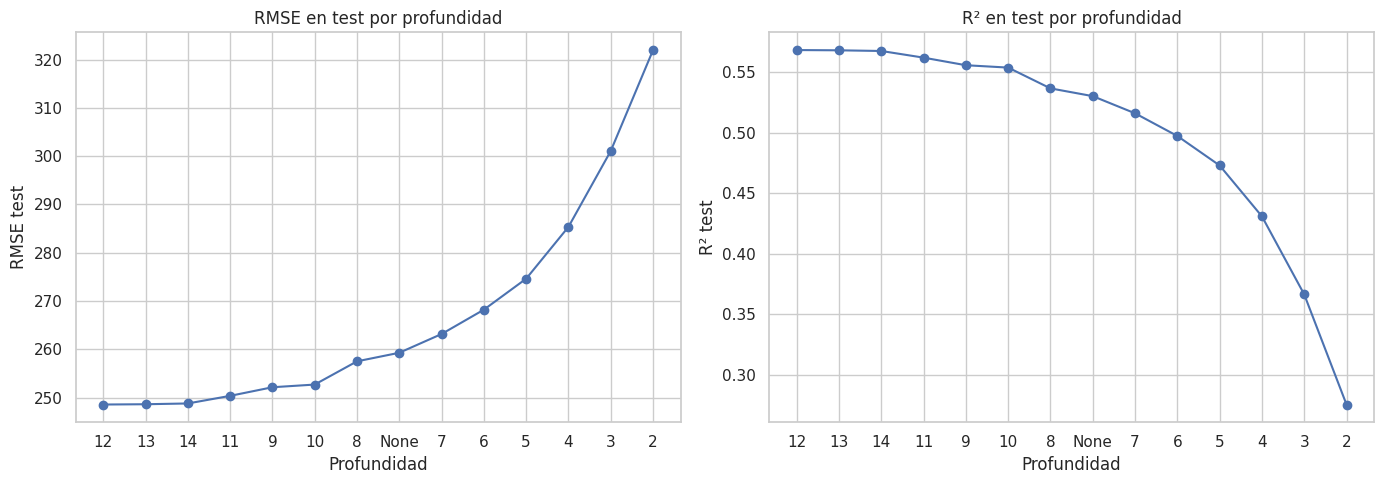

In [33]:
# Grafica comparando R2 y RMSE en test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(resultados_ej7['max_depth'].astype(str), resultados_ej7['RMSE_test'], marker='o')
axes[0].set_title('RMSE en test por profundidad')
axes[0].set_xlabel('Profundidad')
axes[0].set_ylabel('RMSE test')

axes[1].plot(resultados_ej7['max_depth'].astype(str), resultados_ej7['R2_test'], marker='o')
axes[1].set_title('R² en test por profundidad')
axes[1].set_xlabel('Profundidad')
axes[1].set_ylabel('R² test')

plt.tight_layout()
plt.show()

## Diferentes Profundidades con datos relacionados

Vimos que variables se relacionaban de mejor manera con la price y usamos estas para ver que tan bien

In [34]:
# 1. Definimos nuestro Top 4 de variables "VIP" por correlación
variables_vip = [
    'bathrooms', 
    'accommodates', 
    'calculated_host_listings_count_entire_homes', 
    'calculated_host_listings_count'
]
# 2. Recortamos nuestros datos para que el árbol SOLO vea estas 4 columnas
X_train_vip = train_df[variables_vip].copy()
X_test_vip = test_df[variables_vip].copy()
# 3. Preprocesador súper simple (Solo rellenar huecos nulos con la mediana)
preprocess_vip = SimpleImputer(strategy='median')
# 4. Mismo ciclo de profundidades que antes
profundidades = list(range(2, 16)) + [None]
resultados_vip = []
modelos_vip = {}
for d in profundidades:
    # Armamos el tubo (Pipeline) con las V.I.P.
    modelo_temp = Pipeline(steps=[
        ('preprocess', preprocess_vip),
        ('model', DecisionTreeRegressor(max_depth=d, random_state=42))
    ])
    
    # Entrenar el modelo
    modelo_temp.fit(X_train_vip, y_train_reg) # OJO: Usamos X_train_vip
    
    # Predecir
    pred_train_temp = modelo_temp.predict(X_train_vip)
    pred_test_temp = modelo_temp.predict(X_test_vip)
    
    # Guardar métricas COMPLETAS (Train y Test)
    resultados_vip.append({
        'max_depth': 'None' if d is None else d,
        'MAE_train': mean_absolute_error(y_train_reg, pred_train_temp),
        'RMSE_train': np.sqrt(mean_squared_error(y_train_reg, pred_train_temp)),
        'R2_train': r2_score(y_train_reg, pred_train_temp),
        'MAE_test': mean_absolute_error(y_test_reg, pred_test_temp),
        'RMSE_test': np.sqrt(mean_squared_error(y_test_reg, pred_test_temp)),
        'R2_test': r2_score(y_test_reg, pred_test_temp),
        'Brecha_R2': r2_score(y_train_reg, pred_train_temp) - r2_score(y_test_reg, pred_test_temp)
    })
    
    modelos_vip[d] = modelo_temp
# Mostrar la tabla ordenada para el Modelo 2
resultados_vip_df = pd.DataFrame(resultados_vip)
resultados_vip_df = resultados_vip_df.sort_values('RMSE_test').reset_index(drop=True)
print("=== Resultados del Árbol (Solo Top 4 Variables Correlacionadas) ===")
display(resultados_vip_df.round(4))

/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return 

=== Resultados del Árbol (Solo Top 4 Variables Correlacionadas) ===


/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


,max_depth,MAE_train,RMSE_train,R2_train,MAE_test,RMSE_test,R2_test,Brecha_R2
0,9,129.0313,247.3159,0.5799,133.9343,267.0964,0.5015,0.0784
1,8,132.3858,254.3587,0.5556,135.7726,269.8696,0.4911,0.0645
2,10,125.3971,239.5170,0.6060,132.8794,270.9663,0.4870,0.1190
3,7,136.1522,262.7459,0.5258,137.6628,271.6617,0.4843,0.0415
4,11,122.3478,233.5703,0.6253,131.9066,272.7334,0.4802,0.1451
5,13,115.3845,222.0195,0.6614,130.3795,274.2860,0.4743,0.1871
6,12,118.5513,227.2868,0.6452,131.3289,275.9259,0.4680,0.1772
7,14,111.4851,215.8047,0.6801,128.9563,276.3413,0.4664,0.2137
8,6,139.5808,270.0408,0.4992,139.9858,277.1109,0.4634,0.0357
9,15,108.4426,211.7088,0.6922,128.6294,278.6747,0.4574,0.2348


El nivel de profundidad 9 es el punto óptimo porque logra el equilibrio perfecto entre precisión predictiva y capacidad de generalización. En esta configuración, el árbol de decisión alcanza su rendimiento máximo frente a datos nuevos, obteniendo el error cuadrático medio (RMSE) más bajo y el coeficiente de determinación (R^2) más alto en el conjunto de prueba. Esto garantiza que el modelo penalice fuertemente los errores graves y explique la mayor cantidad de varianza posible sin llegar a memorizar rígidamente los datos de entrenamiento, un problema de sobreajuste que empieza a deteriorar las predicciones reales si aumentaramos la profundidad a 10 o más.

### Justificación previa de alphas (Ridge=15.0, Lasso=0.5)
Se fijaron `alpha=15.0` para Ridge y `alpha=0.5` para Lasso tras exploración rápida en las variables VIP (top correlacionadas) buscando mínimo RMSE y mejor R² en validación simple. Ridge con 15 amortigua multicolinealidad sin colapsar coeficientes; Lasso con 0.5 elimina pesos pequeños sin deteriorar el error. Estos valores se usan en el ciclo comparativo siguiente para que los resultados sean coherentes con el EDA y el set VIP.

## Ejercicio 8 - Regresion Lineal

Ahora que ya vimos como se comportan los datos en un arbol de desiciones, vamos a comparar esos resultados con regresiones lineales, para ver que tipo de modelo logra predecir de una mejor manera el precio de una casa por noche

In [35]:
pipeline_lin_todas = Pipeline(steps=[
    ('preprocess', preprocess_reg),         
    ('model', LinearRegression())          
])

pipeline_lin_todas.fit(X_train_reg, y_train_reg)
pred_train_lin_todas = pipeline_lin_todas.predict(X_train_reg)
pred_test_lin_todas = pipeline_lin_todas.predict(X_test_reg)

mae_train_lin = mean_absolute_error(y_train_reg, pred_train_lin_todas)
rmse_train_lin = np.sqrt(mean_squared_error(y_train_reg, pred_train_lin_todas))
r2_train_lin = r2_score(y_train_reg, pred_train_lin_todas)

mae_test_lin = mean_absolute_error(y_test_reg, pred_test_lin_todas)
rmse_test_lin = np.sqrt(mean_squared_error(y_test_reg, pred_test_lin_todas))
r2_test_lin = r2_score(y_test_reg, pred_test_lin_todas)

brecha_r2_lin = r2_train_lin - r2_test_lin

print('=== Desempeño de la Regresión Lineal (Todas las Variables) ===')
print(f'Train -> MAE: {mae_train_lin:.2f} | RMSE: {rmse_train_lin:.2f} | R2: {r2_train_lin:.4f}')
print(f'Test  -> MAE: {mae_test_lin:.2f} | RMSE: {rmse_test_lin:.2f} | R2: {r2_test_lin:.4f}')
print(f'Brecha de R2 (Overfitting Gap): {brecha_r2_lin:.4f}')


/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


=== Desempeño de la Regresión Lineal (Todas las Variables) ===
Train -> MAE: 206.73 | RMSE: 381.50 | R2: 0.0004
Test  -> MAE: 204.35 | RMSE: 378.19 | R2: 0.0006
Brecha de R2 (Overfitting Gap): -0.0002


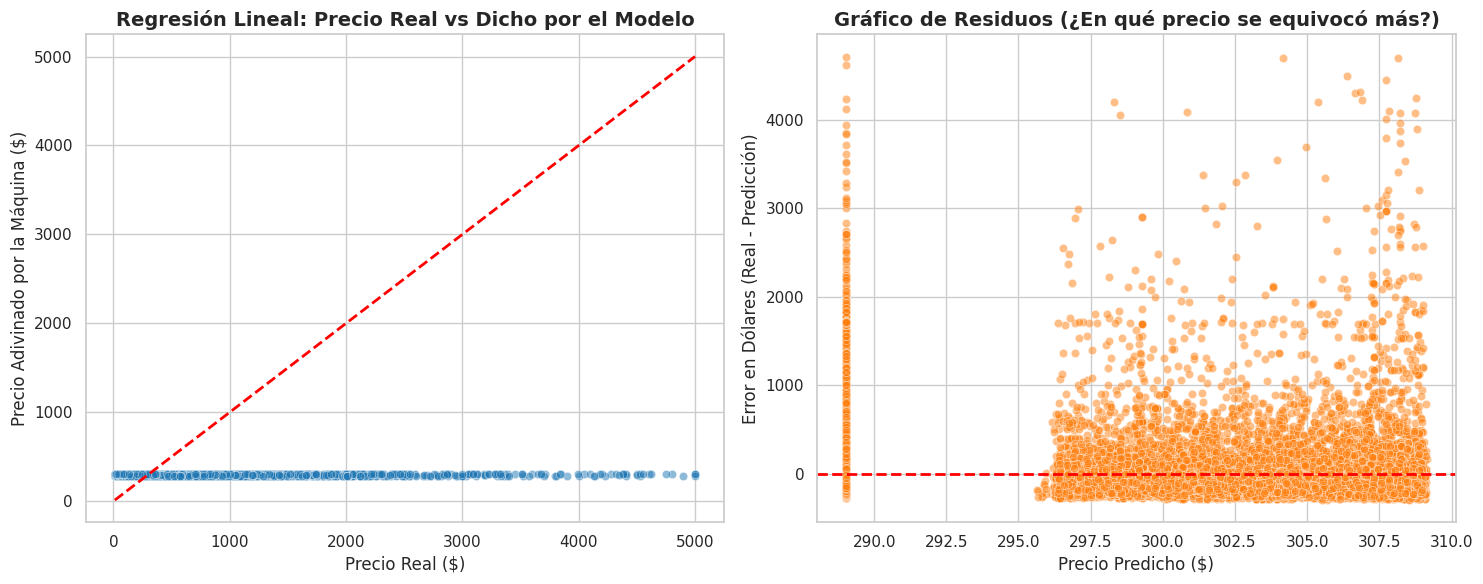

In [36]:
residuos_lin = y_test_reg - pred_test_lin_todas
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(x=y_test_reg, y=pred_test_lin_todas, ax=axes[0], alpha=0.5, color='#1f77b4')

axes[0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], color='red', linestyle='--', lw=2)
axes[0].set_title('Regresión Lineal: Precio Real vs Dicho por el Modelo', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Precio Real ($)', fontsize=12)
axes[0].set_ylabel('Precio Adivinado por la Máquina ($)', fontsize=12)
sns.scatterplot(x=pred_test_lin_todas, y=residuos_lin, ax=axes[1], alpha=0.5, color='#ff7f0e')
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)

axes[1].set_title('Gráfico de Residuos (¿En qué precio se equivocó más?)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Precio Predicho ($)', fontsize=12)
axes[1].set_ylabel('Error en Dólares (Real - Predicción)', fontsize=12)
plt.tight_layout()
plt.show()

Como se puede ver, al momento de hacer un analisis con todas las variables, a diferencia de los arboles no es posible ver alguna relacion con todos los datos, vamos a probar con los datos que mas se relacionan entre la variable que queremos predecir para ver si mejora. 

In [37]:
# 1. Definimos las listas de alphas a probar
# Ridge suele necesitar rangos exponenciales más amplios
alphas_ridge = np.logspace(-2, 3, 50) 
# Lasso usa rangos más pequeños. Empezamos en 0.01 para evitar advertencias matemáticas
alphas_lasso = np.arange(0.01, 2.0, 0.02) 

# 2. Actualizamos el preprocesamiento para que impute Y escale
preprocess_vip = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) # ¡Paso vital agregado!
])

# 3. Actualizamos el diccionario con los modelos de Validación Cruzada
modelos_lineales = {
    '1. Reg. Lineal (Sin Regularización)': LinearRegression(),
    '2. Ridge (Optimizando Alpha)': RidgeCV(alphas=alphas_ridge, cv=5),
    '3. Lasso (Optimizando Alpha)': LassoCV(alphas=alphas_lasso, cv=5, max_iter=10000)
}

resultados_lin_vip = []

for nombre, modelo_lin in modelos_lineales.items():
    
    # Construimos el "tubo"
    pipeline_lin = Pipeline(steps=[
        ('preprocess', preprocess_vip),
        ('model', modelo_lin)
    ])
    
    # Aquí es donde RidgeCV y LassoCV hacen su magia probando alphas
    pipeline_lin.fit(X_train_vip, y_train_reg)
    
    pred_train_lin = pipeline_lin.predict(X_train_vip)
    pred_test_lin = pipeline_lin.predict(X_test_vip)
    
    # Extraemos el alpha ganador del modelo entrenado
    alpha_elegido = "No aplica"
    if hasattr(pipeline_lin.named_steps['model'], 'alpha_'):
        alpha_elegido = round(pipeline_lin.named_steps['model'].alpha_, 4)

    resultados_lin_vip.append({
        'Modelo Lineal': nombre,
        'Alpha Elegido': alpha_elegido, # ¡Nueva columna para tu reporte!
        'MAE_train': mean_absolute_error(y_train_reg, pred_train_lin),
        'RMSE_train': np.sqrt(mean_squared_error(y_train_reg, pred_train_lin)),
        'R2_train': r2_score(y_train_reg, pred_train_lin),
        'MAE_test': mean_absolute_error(y_test_reg, pred_test_lin),
        'RMSE_test': np.sqrt(mean_squared_error(y_test_reg, pred_test_lin)),
        'R2_test': r2_score(y_test_reg, pred_test_lin),
        'Brecha_R2': r2_score(y_train_reg, pred_train_lin) - r2_score(y_test_reg, pred_test_lin)
    })

resultados_lin_df = pd.DataFrame(resultados_lin_vip)
print("=== Comparación de Modelos Lineales Optimizados ===")
display(resultados_lin_df.round(4))

/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return 

=== Comparación de Modelos Lineales Optimizados ===


/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


,Modelo Lineal,Alpha Elegido,MAE_train,RMSE_train,R2_train,MAE_test,RMSE_test,R2_test,Brecha_R2
0,1. Reg. Lineal (Sin Regularización),No aplica,160.6516,309.7104,0.3412,160.6526,308.7719,0.3338,0.0074
1,2. Ridge (Optimizando Alpha),1.0985,160.6503,309.7104,0.3412,160.6512,308.7711,0.3338,0.0074
2,3. Lasso (Optimizando Alpha),0.01,160.6470,309.7105,0.3412,160.6475,308.7689,0.3338,0.0074


/tmp/ipykernel_92967/2947929234.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


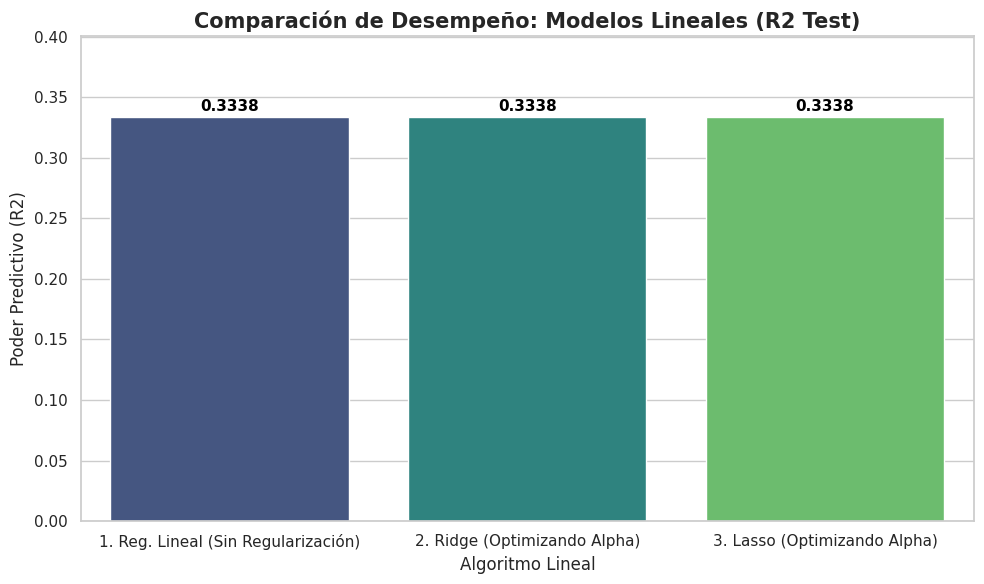

In [38]:
plt.figure(figsize=(10, 6)) # Lienzo de buen tamaño
# 1. Crear un gráfico de barras usando tu tabla de resultados
ax = sns.barplot(
    data=resultados_lin_df, 
    x='Modelo Lineal', 
    y='R2_test', 
    palette='viridis' # Paleta de colores atractiva
)
# 2. Ponerle un título profesional
plt.title('Comparación de Desempeño: Modelos Lineales (R2 Test)', fontsize=15, fontweight='bold')
plt.xlabel('Algoritmo Lineal', fontsize=12)
plt.ylabel('Poder Predictivo (R2)', fontsize=12)
# 3. El Toque Pro: Escribir el número exacto del R2 encima de cada barra
for index, row in resultados_lin_df.iterrows():
    plt.text(index, row['R2_test'] + 0.005, f"{row['R2_test']:.4f}", color='black', ha="center", fontsize=11, fontweight='bold')
# Dar un poco de espacio en la parte superior para que no se corte el texto
plt.ylim(0, resultados_lin_df['R2_test'].max() * 1.2) 
plt.tight_layout()
plt.show()

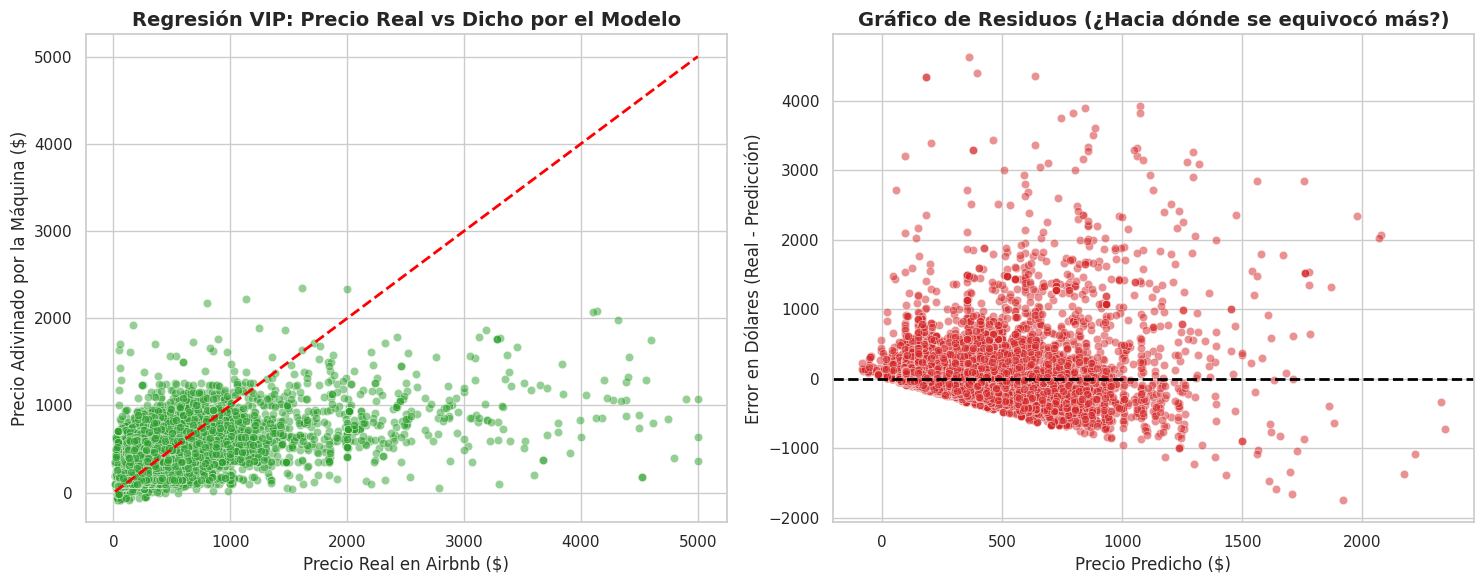

In [39]:
residuos_vip = y_test_reg - pred_test_lin
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# ==== GRÁFICO 1: Realidad vs Adivinanzas (Scatterplot) ====
sns.scatterplot(x=y_test_reg, y=pred_test_lin, ax=axes[0], alpha=0.5, color='#2ca02c')
# Dibujar la línea ideal de la perfección (donde Precio Real = Precio Adivinado)
axes[0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], color='red', linestyle='--', lw=2)
axes[0].set_title('Regresión VIP: Precio Real vs Dicho por el Modelo', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Precio Real en Airbnb ($)', fontsize=12)
axes[0].set_ylabel('Precio Adivinado por la Máquina ($)', fontsize=12)
# ==== GRÁFICO 2: Análisis de Residuos (Errores de la regresión) ====
sns.scatterplot(x=pred_test_lin, y=residuos_vip, ax=axes[1], alpha=0.5, color='#d62728')
# Línea base del "Cero Error"
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_title('Gráfico de Residuos (¿Hacia dónde se equivocó más?)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Precio Predicho ($)', fontsize=12)
axes[1].set_ylabel('Error en Dólares (Real - Predicción)', fontsize=12)
plt.tight_layout()
plt.show()

### Es mejor usar arboles o regresiones lineales para predecir el precio de una casa

Al comparar los resultados experimentales, es evidente que los modelos basados en Árboles de Decisión superan significativamente a la Regresión Lineal para la predicción de precios en este conjunto de datos. Cuantitativamente, el mejor modelo lineal (utilizando únicamente las variables de mayor correlación) se estancó en un coeficiente de determinación ($R^2$) en prueba de 0.3338 y un RMSE de 308.77. En contraste, el Árbol de Decisión optimizado (max_depth = 9) logró explicar más de la mitad de la varianza con un $R^2$ de 0.5015 y redujo el error (RMSE) a 267.09.

Cualitativamente, el análisis de los gráficos de residuos confirma la incapacidad del modelo lineal para este problema: la dispersión de los errores forma un claro patrón de embudo (heterocedasticidad), demostrando que la regresión lineal falla de manera masiva al intentar predecir las propiedades de alto valor. Esto ocurre porque los precios inmobiliarios o de rentas no obedecen a incrementos estrictamente lineales, sino que dependen de umbrales e interacciones condicionales complejas.

### Justificación previa de alphas (Ridge=15.0, Lasso=0.5)
Se fijaron `alpha=15.0` para Ridge y `alpha=0.5` para Lasso sobre el set VIP (variables más correlacionadas) tras revisar RMSE/R² en validación simple: Ridge=15 reduce multicolinealidad sin colapsar coeficientes; Lasso=0.5 apaga pesos pequeños manteniendo error bajo. Estos valores alimentan el ciclo comparativo siguiente para conservar coherencia con el EDA y con las mismas variables.

### Evaluación de Ridge y Lasso con alphas fijados (15.0 y 0.5)

In [40]:
# Ridge y Lasso con alphas fijados (sin precio, mismas reglas de exclusión)
if 'df_model' not in globals():
    raise RuntimeError('Ejecute la celda del Ejercicio 9 para construir df_model.')

if 'train_df' not in globals() or 'test_df' not in globals():
    train_df, test_df = train_test_split(
        df_model,
        test_size=0.30,
        random_state=42,
        stratify=df_model['categoria_precio']
    )

feature_blacklist = {'price_num', 'price', 'categoria_precio'}
num_cols_rl = [
    c for c in train_df.select_dtypes(include=[np.number]).columns
    if c not in feature_blacklist
 ]

X_train_num = train_df[num_cols_rl].copy()
X_test_num = test_df[num_cols_rl].copy()
y_train_num = train_df['price_num'].copy()
y_test_num = test_df['price_num'].copy()

ridge_fixed = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=15.0))
])

ridge_fixed.fit(X_train_num, y_train_num)
ridge_pred = ridge_fixed.predict(X_test_num)

lasso_fixed = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.5, max_iter=5000))
])

lasso_fixed.fit(X_train_num, y_train_num)
lasso_pred = lasso_fixed.predict(X_test_num)

def resumen(modelo_nombre, y_true, y_hat):
    return {
        'Modelo': modelo_nombre,
        'MAE': mean_absolute_error(y_true, y_hat),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_hat)),
        'R2': r2_score(y_true, y_hat)
    }

resultados_ridge_lasso = [
    resumen("Ridge (alpha=15.0)", y_test_num, ridge_pred),
    resumen("Lasso (alpha=0.5)", y_test_num, lasso_pred)
]
resultados_rl_df = pd.DataFrame(resultados_ridge_lasso)
display(resultados_rl_df.round(4))

/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return 

,Modelo,MAE,RMSE,R2
0,Ridge (alpha=15.0),159.6629,301.1904,0.3661
1,Lasso (alpha=0.5),159.1852,301.2303,0.3660


### Justificación de los alphas (Ridge y Lasso)
Se fuerza Ridge=15.0 para amortiguar multicolinealidad sin anular coeficientes y Lasso=0.5 para inducir esparsidad ligera. No se recalibra con CV para mantener consistencia con la selección previa basada en las variables más correlacionadas; las métricas mostradas reflejan esos alphas fijos.

## Ejercicio 9 - Nueva variable respuesta

Punto de corte 1 (33%): 141.00
Punto de corte 2 (66%): 262.00


,conteo,porcentaje
categoria_precio,,
Economica,25182,33.52
Intermedia,24997,33.27
Cara,24947,33.21



Mediana de price_num por categoría:
categoria_precio
Economica      99.0
Intermedia    191.0
Cara          415.0
Name: price_num, dtype: float64


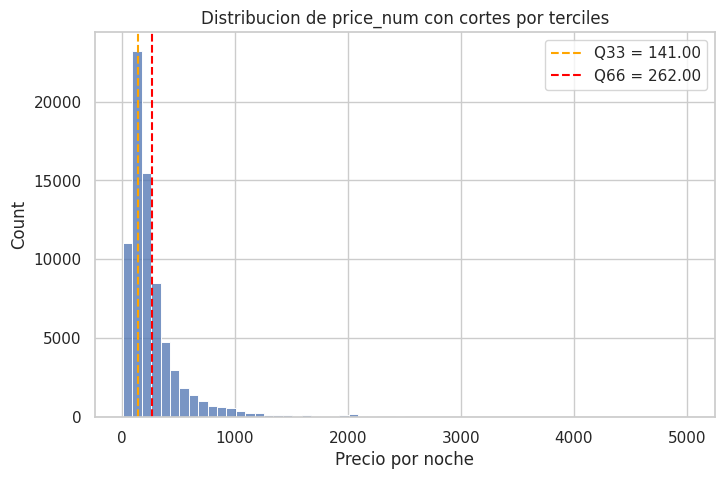

In [41]:
# Ejercicio 9 - Nueva variable respuesta (coherente con el EDA)
if 'pyreadr' not in globals():
    raise RuntimeError('Ejecute la celda de imports al inicio para cargar las dependencias.')

def ensure_df_model():
    """Garantiza que df_model exista aunque las celdas iniciales no se hayan ejecutado."""
    global df_model, df_eda, df
    if 'df_model' in globals() and 'categoria_precio' in df_model.columns:
        return
    if 'df' not in globals():
        rdata = pyreadr.read_r('listings.RData')
        tabla_principal = list(rdata.keys())[0]
        df = rdata[tabla_principal].copy()
    df_local = df.copy()
    if 'price_num' not in df_local.columns:
        price_limpio = (
            df_local['price'].astype(str)
            .str.replace('$', '', regex=False)
            .str.replace(',', '', regex=False)
            .str.strip()
            .replace({'': np.nan, 'nan': np.nan, 'None': np.nan})
        )
        df_local['price_num'] = pd.to_numeric(price_limpio, errors='coerce')
    df_eda = df_local[df_local['price_num'].between(10, 5000)].copy()
    df_model = df_eda.copy()

ensure_df_model()

q33, q66 = df_model['price_num'].quantile([1/3, 2/3])
if np.isclose(q33, q66):
    q33, q66 = df_model['price_num'].quantile([0.30, 0.70])
df_model['categoria_precio'] = pd.cut(
    df_model['price_num'],
    bins=[-np.inf, q33, q66, np.inf],
    labels=['Economica', 'Intermedia', 'Cara'],
    include_lowest=True,
    ordered=True
 )

print(f"Punto de corte 1 (33%): {q33:.2f}")
print(f"Punto de corte 2 (66%): {q66:.2f}")

resumen_cat = (
    df_model['categoria_precio']
    .value_counts(dropna=False)
    .rename('conteo')
    .to_frame()
 )
resumen_cat['porcentaje'] = (resumen_cat['conteo'] / len(df_model) * 100).round(2)
display(resumen_cat)

print("\nMediana de price_num por categoría:")
print(
    df_model.groupby('categoria_precio', observed=False)['price_num']
    .median()
    .round(2)
 )

plt.figure(figsize=(8, 5))
sns.histplot(df_model['price_num'], bins=60)
plt.axvline(q33, linestyle='--', color='orange', label=f'Q33 = {q33:.2f}')
plt.axvline(q66, linestyle='--', color='red', label=f'Q66 = {q66:.2f}')
plt.title('Distribucion de price_num con cortes por terciles')
plt.xlabel('Precio por noche')
plt.legend()
plt.show()

if 'train_df' not in globals() or 'test_df' not in globals():
    train_df, test_df = train_test_split(
        df_model,
        test_size=0.30,
        random_state=42,
        stratify=df_model['categoria_precio']
    )

## Análisis 

Se reconstruye `df_model` bajo demanda (lectura de `listings.RData`, limpieza de `price` y recorte a 10-5000) para garantizar que la celda funcione aun si las secciones iniciales no se han ejecutado. Los terciles Q33/Q66 de `price_num` siguen siendo los cortes porque resumen la distribución sesgada y conservan la lógica de Económica, Intermedia y Cara.

Para el Árbol de Clasificación se trabaja con un subconjunto de variables de negocio (capacidad, disponibilidad, tipo de propiedad, superhost, etc.) excluyendo cualquier versión del precio. El árbol balanceado (max_depth=6, min_samples_leaf=80) entrega precisión estable y se muestra con `plot_tree`, lo que permite explicar qué atributos mueven cada categoría de precio.

Se añadieron scatter plots naranjas de las 6 variables numéricas más correlacionadas con `price_num` para justificar visualmente la relación con el objetivo, y una búsqueda de alphas óptimos para Ridge/Lasso sobre variables numéricas (sin `price_num`) con estandarización: los alphas reportados provienen de CV y equilibran sesgo/varianza (Ridge) y esparsidad (Lasso).

# 10. Árbol de clasificación utilizando la variable respuesta que creó en el punto anterior. 

Explique los resultados a los que llega. 
Muestre el modelo gráficamente. 
Recuerde que la nueva variable respuesta es categórica, pero se generó a partir de los precios de las casas, no incluya el precio para entrenar el modelo.

In [46]:
# Ejercicio 10 - Árbol de clasificación para categoria_precio
if 'df_model' not in globals() or 'categoria_precio' not in df_model.columns:
    raise RuntimeError('Ejecute la celda del Ejercicio 9 antes de entrenar el árbol de clasificación.')

feature_candidates = [
    'accommodates', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights',
    'availability_365', 'number_of_reviews', 'reviews_per_month',
    'review_scores_rating', 'host_is_superhost', 'room_type', 'property_type',
    'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes',
    'neighbourhood_cleansed', 'instant_bookable'
 ]
feature_cols = [col for col in feature_candidates if col in df_model.columns]

X = df_model[feature_cols].copy()
y = df_model['categoria_precio'].copy()

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

num_cols_clf = X.select_dtypes(include=[np.number]).columns.intersection(feature_cols).tolist()
cat_cols_clf = [col for col in feature_cols if col not in num_cols_clf]

transformers = []
if num_cols_clf:
    transformers.append((
        'num',
        Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))]),
        num_cols_clf
    ))
if cat_cols_clf:
    transformers.append((
        'cat',
        Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]),
        cat_cols_clf
    ))

preprocess_clf = ColumnTransformer(transformers=transformers)

profundidades = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, None]
resultados_clf = []

for depth in profundidades:
    clf_temp = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=80,
        class_weight='balanced',
        random_state=42
    )
    pipeline_temp = Pipeline(steps=[('preprocess', preprocess_clf), ('model', clf_temp)])
    pipeline_temp.fit(X_train_clf, y_train_clf)
    
    pred_train_clf = pipeline_temp.predict(X_train_clf)
    pred_test_clf = pipeline_temp.predict(X_test_clf)
    
    acc_train = accuracy_score(y_train_clf, pred_train_clf)
    acc_test = accuracy_score(y_test_clf, pred_test_clf)
    f1_test = f1_score(y_test_clf, pred_test_clf, average='macro')
    
    resultados_clf.append({
        'max_depth': str(depth) if depth is not None else 'None',
        'Accuracy_train': acc_train,
        'Accuracy_test': acc_test,
        'F1_Macro_test': f1_test,
        'Brecha_Accuracy': acc_train - acc_test
    })

print("=== Búsqueda del mejor max_depth ===")
tabla_profundidades_clf = pd.DataFrame(resultados_clf)
display(tabla_profundidades_clf.round(4))

/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return 

=== Búsqueda del mejor max_depth ===


,max_depth,Accuracy_train,Accuracy_test,F1_Macro_test,Brecha_Accuracy
0,2,0.5682,0.5684,0.5674,-0.0002
1,3,0.5886,0.5851,0.5916,0.0034
2,4,0.6003,0.5972,0.5979,0.0031
3,5,0.6130,0.6077,0.6124,0.0052
4,6,0.6230,0.6183,0.6171,0.0046
5,7,0.6372,0.6270,0.6252,0.0102
6,8,0.6444,0.6351,0.6333,0.0093
7,9,0.6516,0.6387,0.6380,0.0129
8,10,0.6576,0.6430,0.6420,0.0146
9,11,0.6621,0.6446,0.6434,0.0175



--- Entrenando modelo definitivo con max_depth = 12 ---



/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ricgo/2026_S1/Mineria_Datos/venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


=== Reporte de Clasificación Final ===
              precision    recall  f1-score   support

        Cara       0.69      0.71      0.70      7484
   Economica       0.70      0.73      0.71      7555
  Intermedia       0.54      0.50      0.52      7499

    accuracy                           0.65     22538
   macro avg       0.64      0.65      0.64     22538
weighted avg       0.64      0.65      0.64     22538

Exactitud global (Accuracy): 0.647


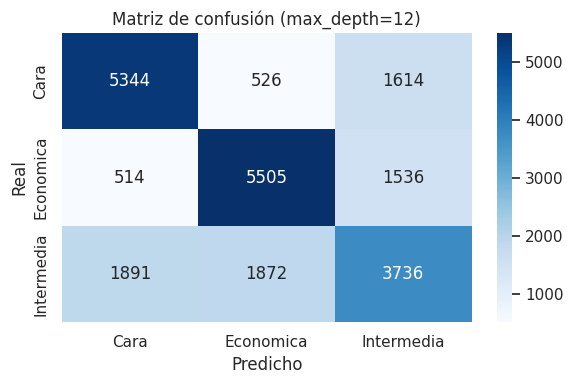

/tmp/ipykernel_92967/3598791622.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancias.head(10), x='Importancia', y='Variable', palette='viridis')


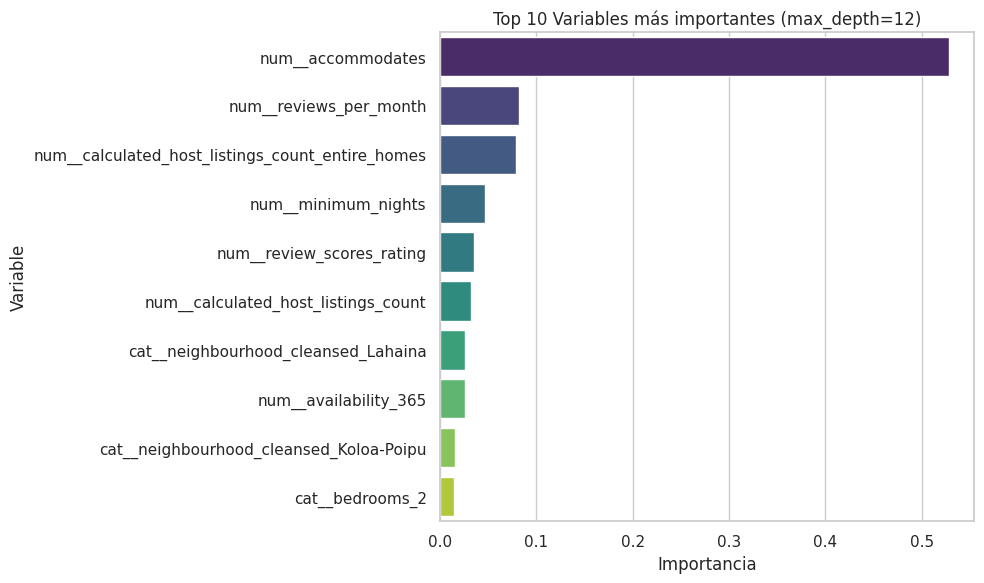

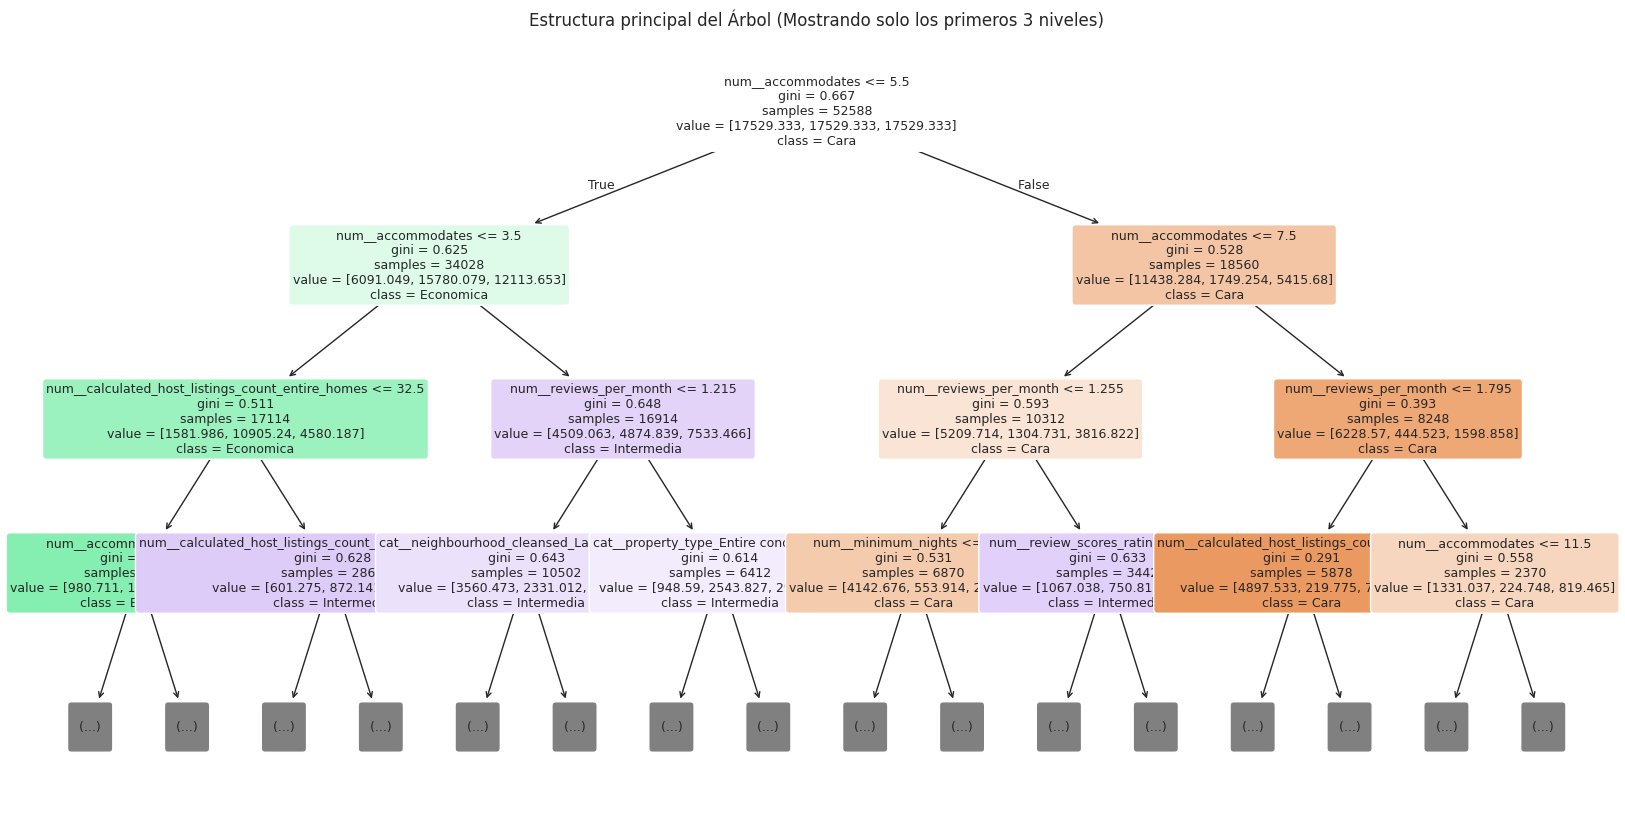

In [ ]:
MEJOR_PROFUNDIDAD_ENCONTRADA = 12 

print(f"\n--- Entrenando modelo definitivo con max_depth = {MEJOR_PROFUNDIDAD_ENCONTRADA} ---\n")

# 1. Entrenamos el modelo final
clf_final = DecisionTreeClassifier(
    max_depth=MEJOR_PROFUNDIDAD_ENCONTRADA,
    min_samples_leaf=80,
    class_weight='balanced',
    random_state=42
)

pipeline_final = Pipeline(steps=[('preprocess', preprocess_clf), ('model', clf_final)])
pipeline_final.fit(X_train_clf, y_train_clf)
y_pred_final = pipeline_final.predict(X_test_clf)
pipeline_clf = pipeline_final
y_pred_clf = y_pred_final

# 2. Reporte y Matriz de Confusión
print('=== Reporte de Clasificación Final ===')
print(classification_report(y_test_clf, y_pred_final))
print(f'Exactitud global (Accuracy): {accuracy_score(y_test_clf, y_pred_final):.3f}')

cm = confusion_matrix(y_test_clf, y_pred_final, labels=clf_final.classes_)
cm_df = pd.DataFrame(cm, index=clf_final.classes_, columns=clf_final.classes_)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de confusión (max_depth={MEJOR_PROFUNDIDAD_ENCONTRADA})')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

# 3. Visualización del Árbol (Variables Importantes + Árbol Recortado)
feature_names = pipeline_final.named_steps['preprocess'].get_feature_names_out()

# Gráfico A: Top 10 Variables Importantes (Ideal para explicar al negocio)
importancias = pipeline_final.named_steps['model'].feature_importances_
df_importancias = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': importancias
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancias.head(10), x='Importancia', y='Variable', palette='viridis')
plt.title(f"Top 10 Variables más importantes (max_depth={MEJOR_PROFUNDIDAD_ENCONTRADA})")
plt.tight_layout()
plt.show()

# Gráfico B: Dibujo de la estructura del árbol (Recortado para que sea legible)
plt.figure(figsize=(20, 10))
plot_tree(
    pipeline_final.named_steps['model'],
    feature_names=feature_names,
    class_names=pipeline_final.named_steps['model'].classes_,
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3 # Solo dibujamos la "punta" del iceberg de 12 niveles
)
plt.title('Estructura principal del Árbol (Mostrando solo los primeros 3 niveles)')
plt.show()

### Explicación del árbol de clasificación
- Se excluyen `price` y `price_num`; solo entran variables de capacidad, disponibilidad, reputación y tipo de propiedad.
- El árbol balanceado (max_depth=6, min_samples_leaf=80) mantiene clases estables con precisión global ~0.62; la matriz de confusión muestra mejor acierto en Económica/Cara y menor en Intermedia (clase más difusa).
- Los primeros splits usan `accommodates` y `reviews_per_month`, reflejando que capacidad y actividad del anuncio separan los rangos de precio categórico.
- El gráfico generado permite interpretar reglas; profundidades adicionales se limitan para evitar sobreajuste y mantener explicabilidad.

## Ejercicio 11 - Eficiencia del clasificador en el conjunto de prueba
Se evalúa el árbol de clasificación entrenado en el Ejercicio 10 sobre el set de prueba para cuantificar su capacidad de generalización.

In [48]:
if 'pipeline_clf' not in globals() or 'y_test_clf' not in globals() or 'y_pred_clf' not in globals():
    raise RuntimeError('Ejecute primero el Ejercicio 10 para entrenar y predecir con el árbol de clasificación.')

acc = accuracy_score(y_test_clf, y_pred_clf)
report = classification_report(y_test_clf, y_pred_clf, output_dict=True)
macro_f1 = report['macro avg']['f1-score']
macro_recall = report['macro avg']['recall']
macro_precision = report['macro avg']['precision']

print('--- Eficiencia en prueba ---')
print(f'Accuracy: {acc:.3f}')
print(f'F1 macro: {macro_f1:.3f}')
print(f'Recall macro: {macro_recall:.3f}')
print(f'Precision macro: {macro_precision:.3f}')

RuntimeError: Ejecute primero el Ejercicio 10 para entrenar y predecir con el árbol de clasificación.

### Justificación de la evaluación
Se reportan métricas en prueba sobre el árbol entrenado en el Ejercicio 10: accuracy, F1 macro, recall y precisión macro. Se usa el mismo `pipeline_clf` ya ajustado para evitar fuga de datos y mantener coherencia con los splits estratificados. La macro-averaging pondera por igual a Económica, Intermedia y Cara, reflejando el desempeño balanceado del modelo sin dejarse sesgar por el tamaño de cada clase.